# Power of d Choices

A store has 7 checkout lines. Each time step a shopper arrives with probability 0.98, looks at `d` randomly chosen
lines and joins the shortest; each line with someone in it checks out its front shopper with probability 0.15.
The total checkout capacity is 7 × 0.15 = 1.05 shoppers per step, so the store runs at 93% utilization.

How much does looking at more lines help? Every value of `d` sees the same arrivals, line orders and checkout
events (common random numbers), so the comparison is paired. The seven runs execute in parallel, one process
each.

In [1]:
import sys
from concurrent.futures import ProcessPoolExecutor
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))  # project root, so checkout_queues imports without installing
from checkout_queues.sim_worker import random_inputs, simulate_store

total_time = 45_000
p_shopper = 0.98
p_checkout = 0.15
lines = 7

inputs = random_inputs(total_time, lines, p_shopper, p_checkout, rng=1)
ds = range(1, lines + 1)
with ProcessPoolExecutor() as pool:
    results = dict(zip(ds, pool.map(partial(simulate_store, arrivals=inputs[0], line_orders=inputs[1],
                                            checkouts=inputs[2]), ds)))

## Line length over time

Average line length, smoothed over 500 steps. With `d = 1` the lines behave like independent, heavily loaded queues
and drift far from their mean; inspecting even a second line pulls them back. The bursts that line up across all
values of d are the shared random inputs at work: every d sees the same runs of arrivals and slow checkouts.

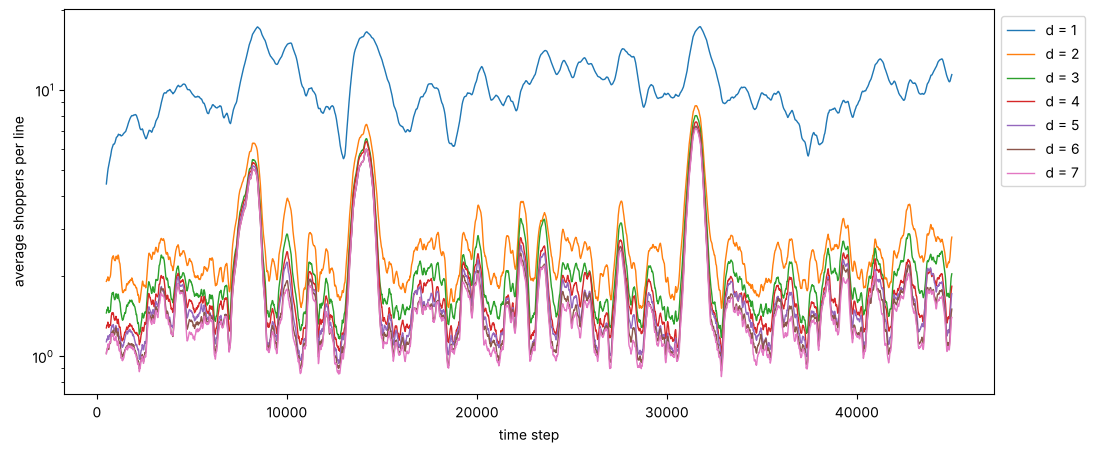

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))
for d, df in results.items():
    ax.plot(df["time"], df["avg_shoppers"].rolling(500).mean(), lw=1, label=f"d = {d}")
ax.set_xlabel("time step")
ax.set_ylabel("average shoppers per line")
ax.set_yscale("log")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

## Summary

Mean line length and mean wait, discarding the first 5,000 steps as warm-up. The last column checks the waits
against Little's law, $W = L / \lambda$: the mean number of shoppers in the store divided by the arrival rate.

,avg_shoppers_per_line,avg_wait,littles_law_wait
d,,,
1,10.55,75.45,75.30
2,2.73,19.39,19.51
3,2.20,15.56,15.69
4,1.96,13.83,13.97
5,1.82,12.81,12.96
6,1.72,12.15,12.30
7,1.66,11.74,11.88


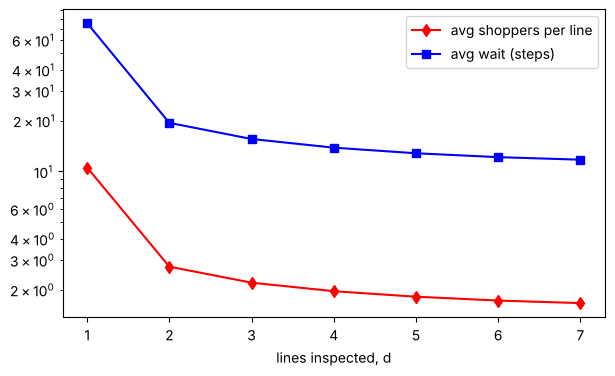

In [3]:
warmup = 5000
summary = pd.DataFrame({
    d: {"avg_shoppers_per_line": df["avg_shoppers"][warmup:].mean(),
        "avg_wait": df["avg_wait"][warmup:].mean()}
    for d, df in results.items()
}).T.rename_axis("d")
summary["littles_law_wait"] = lines * summary["avg_shoppers_per_line"] / inputs[0][warmup:].mean()
display(summary.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(summary.index, summary["avg_shoppers_per_line"], "r-d", label="avg shoppers per line")
ax.semilogy(summary.index, summary["avg_wait"], "b-s", label="avg wait (steps)")
ax.set_xlabel("lines inspected, d")
ax.legend()
plt.show()

Most of the gain comes from the second choice: going from 1 to 2 lines inspected cuts the average line length by
roughly a factor of four, while inspecting all 7 lines improves on 2 by much less.